In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import os
import re
from pathlib import Path

In [48]:
driver = "nSyb"
responder = "eOPN3"
time ="5s"
genotypefilename = driver + " x " + responder
control1name = "w1118 x " + driver
control2name = "w1118 x " + responder


if responder == "eOPN3":
    responderrename = "AsOPN3"
if responder == "ACR":
    responderrename = "GtACR1"
transgenicnaming = driver + " > " + responderrename

base_path = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data\\TruMelan\\Reformatted\\"  

# output_dir = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\Trumelan\\Trumelan images"  

# Analysis parameters
bin_size = 0.5  # seconds for heatmap resampling
framerate = 10  # Hz
illum_start = 60  # illumination start (seconds)
illum_duration = 5  # illumination duration (seconds)


#exp_path = "D:\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data\\TruMelan\\Jonny\\eOPN3 PIEZO\\Piezo x eOPN3_Green_1s"

exp_path = base_path + genotypefilename
control1_path = base_path + control1name
control2_path = base_path + control2name

## Functions

In [61]:
def load_csv_data(folder_path, metric_col, time_filter=None):
    """Load and process CSV data for given metric with optional time filtering."""
    csv_files = glob.glob(os.path.join(folder_path, "*.csv"))
    if not csv_files:
        return None
    
    # Filter files by time parameter if specified
    if time_filter:
        time_pattern = f"_{time_filter}_"
        csv_files = [f for f in csv_files if time_pattern in os.path.basename(f)]   
    
    data_list = []
    
    for i, file in enumerate(csv_files, start=1):
            df = pd.read_csv(file, usecols=["Timestamp (ms)", metric_col])
            # Convert to seconds and start at 0
            df["Time (s)"] = (df["Timestamp (ms)"] - df["Timestamp (ms)"].iloc[0]) / 1000
            df = df.set_index("Time (s)")
            df = df[[metric_col]]
            df.rename(columns={metric_col: f"{i}"}, inplace=True)
            data_list.append(df)
    
    if not data_list:
        print(f"No valid data loaded from {folder_path}")
        return None
    
    return pd.concat(data_list, axis=1)

def create_heatmap(data, title, max_time=None, log_transform=True):
    """Create heatmap for given data."""
    if data is None:
        print(f"No data available for {title}")
        return
    
    # Limit time range
    data_subset = data[data.index <= max_time]
    
    # Resample to bin_size intervals
    data_resampled = data_subset.groupby((data_subset.index // bin_size) * bin_size).mean()
    
    # Log transform if requested
    if log_transform:
        data_transformed = np.log10(data_resampled + 1)
        cbar_label = f'{title.split(" for ")[0]} (log10)'
    else:
        data_transformed = data_resampled
        cbar_label = title.split(" for ")[0]
    
    # Transpose for heatmap
    heatmap_data = data_transformed.T
    
    plt.figure(figsize=(14, 8))
    sns.heatmap(
        heatmap_data,
        cmap="viridis",
        cbar_kws={'label': cbar_label},
        xticklabels=12,
        yticklabels=True
    )
    
    plt.yticks(fontsize=6)
    
    # Add illumination lines
    illum_start_idx = int(illum_start // bin_size)
    illum_end_idx = int((illum_start + illum_duration) // bin_size)
    plt.axvline(x=illum_start_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)
    plt.axvline(x=illum_end_idx, color='white', linewidth=2, linestyle='--', alpha=1.0)
    
    plt.xlabel("Time (seconds)")
    plt.ylabel("Fly")
    plt.title(title)
    plt.tight_layout()
    
    return plt.gcf()

def create_linegraph(data_dict, title, max_time = None, smoothing_window=5):
    """Create linegraph comparing multiple genotypes."""
    plt.figure(figsize=(12, 7), dpi=300)
    
    colors = ["#000000", "#3027AE", "#AE2730", "#27AE60"]
    color_idx = 0
    
    for label, data in data_dict.items():
        if data is None:
            continue
            
        # Limit time range
        data_subset = data[data.index <= max_time]
        
        # Create uniform time grid
        time_step = 1 / framerate
        time_grid = np.arange(0, max_time, time_step)
        
        # Interpolate data to uniform grid
        aligned_data = []
        for col in data_subset.columns:
            interp_series = pd.Series(
                np.interp(time_grid, data_subset.index, data_subset[col]),
                index=time_grid
            )
            aligned_data.append(interp_series)
        
        all_data = pd.concat(aligned_data, axis=1)
        
        # Smooth with rolling mean
        window = framerate * smoothing_window
        smoothed = all_data.rolling(window=window, min_periods=1, center=True).mean()
        
        # Compute mean and 95% CI
        mean_val = smoothed.mean(axis=1)
        std_val = smoothed.std(axis=1)
        n = smoothed.shape[1]
        ci_upper = mean_val + 1.96 * (std_val / n**0.5)
        ci_lower = mean_val - 1.96 * (std_val / n**0.5)
        
        color = colors[color_idx % len(colors)]
        label_with_n = f"{label} (n={n})"
        plt.plot(mean_val.index, mean_val.values, color=color, linewidth=2, label=label_with_n)
        plt.fill_between(mean_val.index, ci_lower, ci_upper, color=color, alpha=0.15)
        
        color_idx += 1
    
    # Add illumination rectangle
    ylim = plt.ylim()
    plt.gca().add_patch(
        plt.Rectangle(
            (illum_start, ylim[0]),
            illum_duration,
            ylim[1] - ylim[0],
            color="#58D68D",
            alpha=0.3
        )
    )
    
    plt.xlabel("Time (s)", fontsize=12, labelpad=8)
    plt.ylabel(title.split(" for ")[0], fontsize=12, labelpad=8)
    plt.title(title, fontsize=14, pad=12)
    plt.xlim(0, max_time)
    plt.ylim(bottom=0)
    
    plt.legend(frameon=False, fancybox=False, edgecolor='black',
               handlelength=3, handleheight=2, handletextpad=1.2,
               borderpad=1.2, loc="upper right")
    plt.tight_layout()
    
    return plt.gcf()

## Heatmap

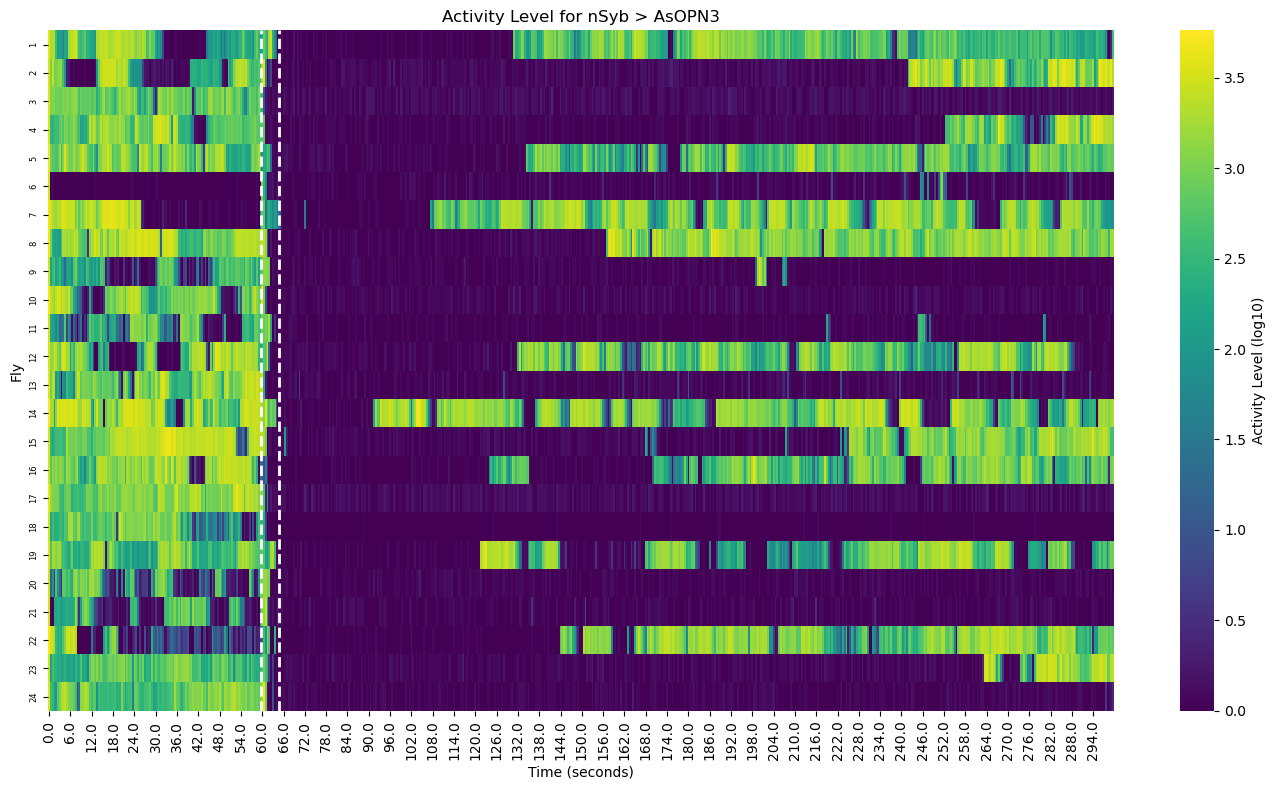

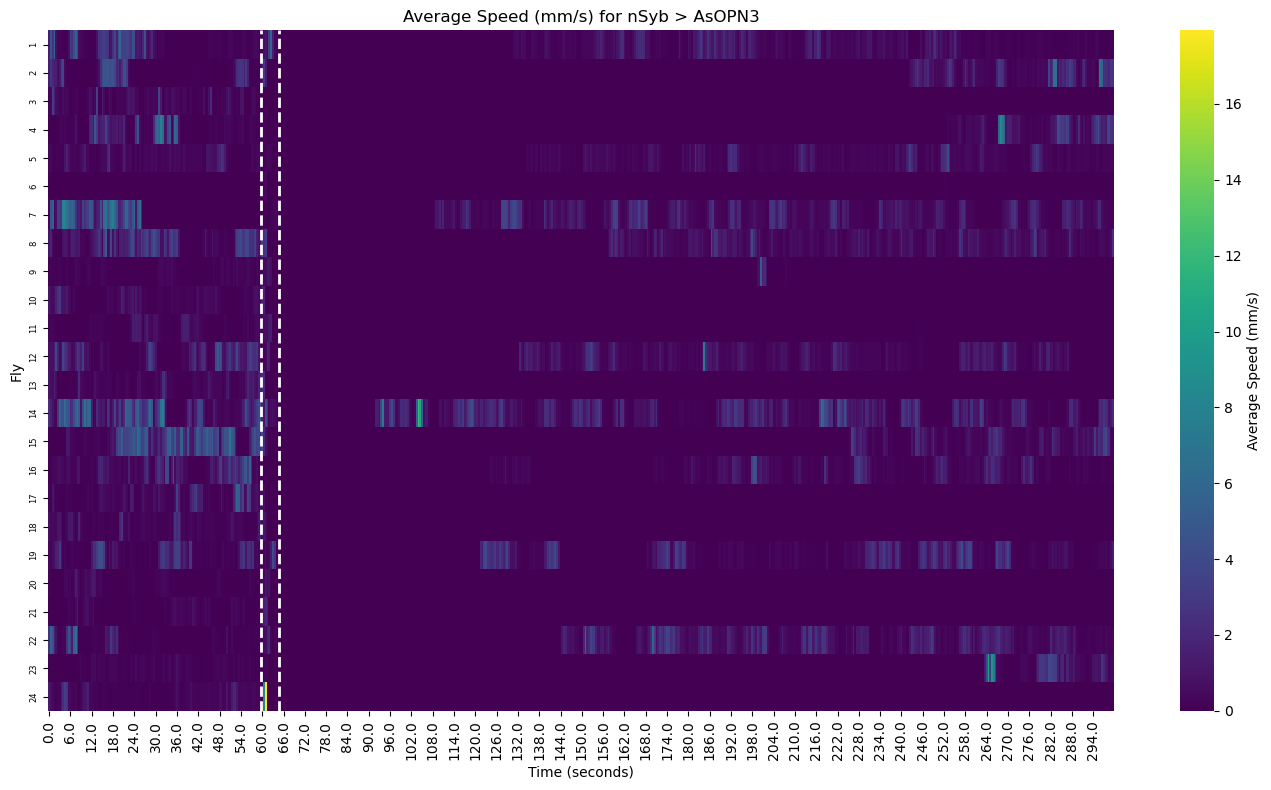

In [63]:
metrics = ["Activity Level", "Speed_Av_mm_per_sec"]
metric_labels = ["Activity Level", "Average Speed (mm/s)"]

# Check if folders exist
folders_exist = {
    "experimental": os.path.exists(exp_path),
}


for metric, metric_label in zip(metrics, metric_labels):
    
    # Load experimental data with time filter
    if folders_exist["experimental"]:
        exp_data = load_csv_data(exp_path, metric, time_filter=time)
        if exp_data is not None:
            fig = create_heatmap(
                exp_data, 
                f"{metric_label} for {transgenicnaming}", max_time = 300,
                log_transform=(metric == "Activity Level")
            )
            
            # Save heatmap (uncomment if output_dir is defined)
            # filename = f"{genotypefilename}_{metric.replace(' ', '_').lower()}_heatmap.svg"
            # fig.savefig(os.path.join(output_dir, filename))
            plt.show()
        else:
            print(f"No data found in {exp_path}")
    else:
        print(f"Experimental folder not found: {exp_path}")

Time filter '5s' applied: 24 files found


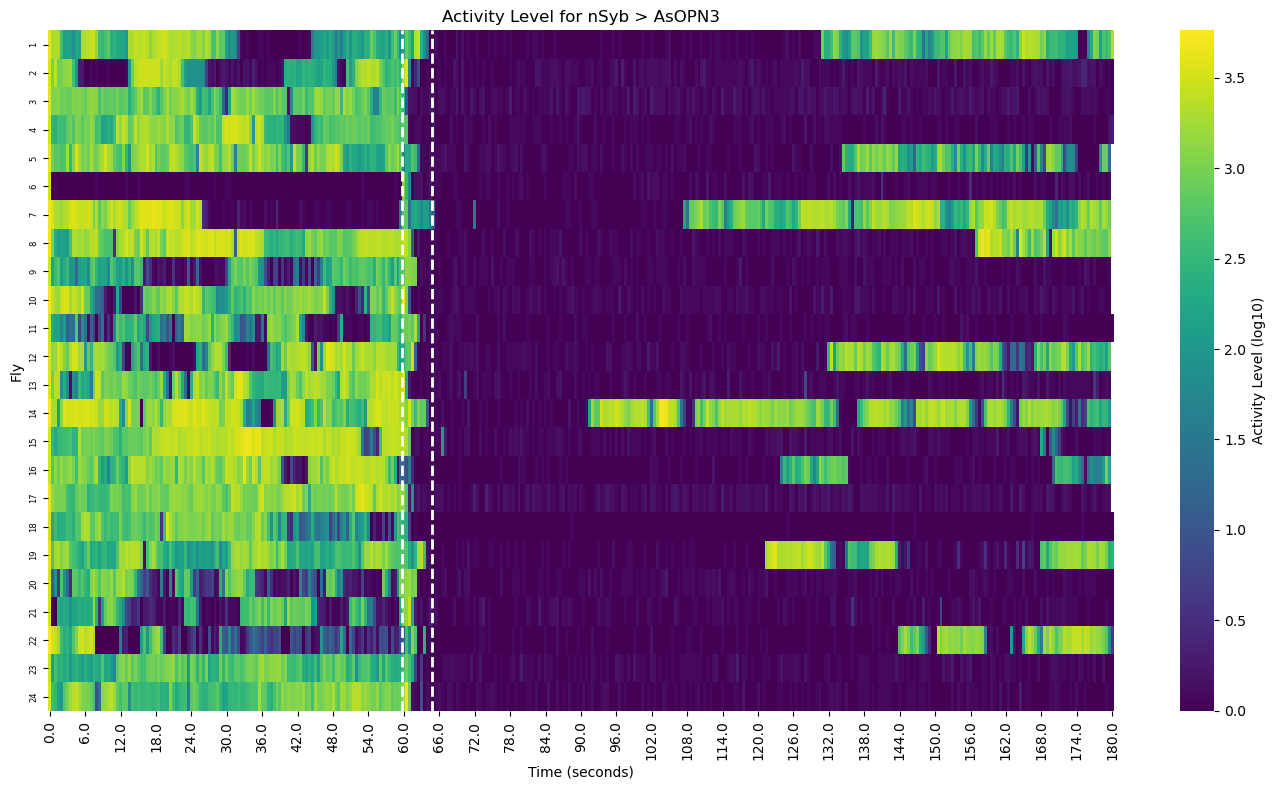

Time filter '5s' applied: 22 files found


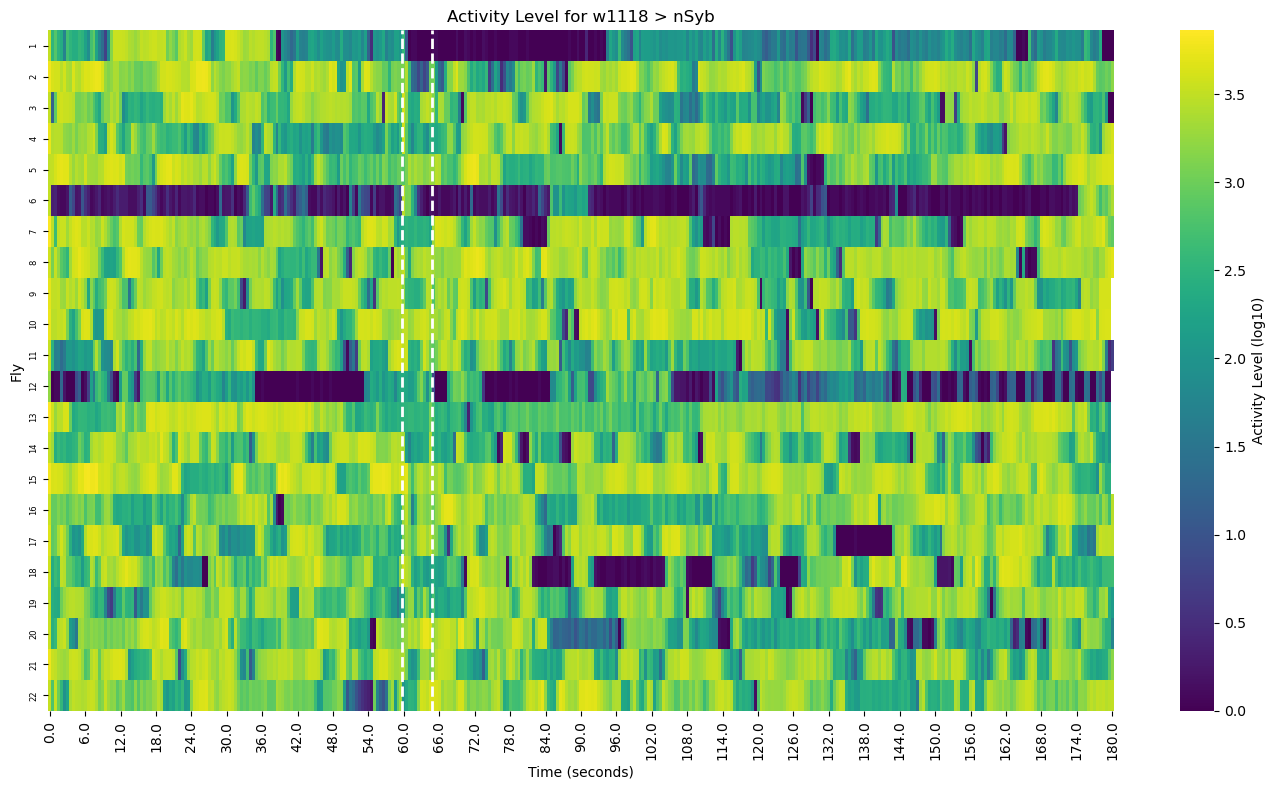

Time filter '5s' applied: 24 files found


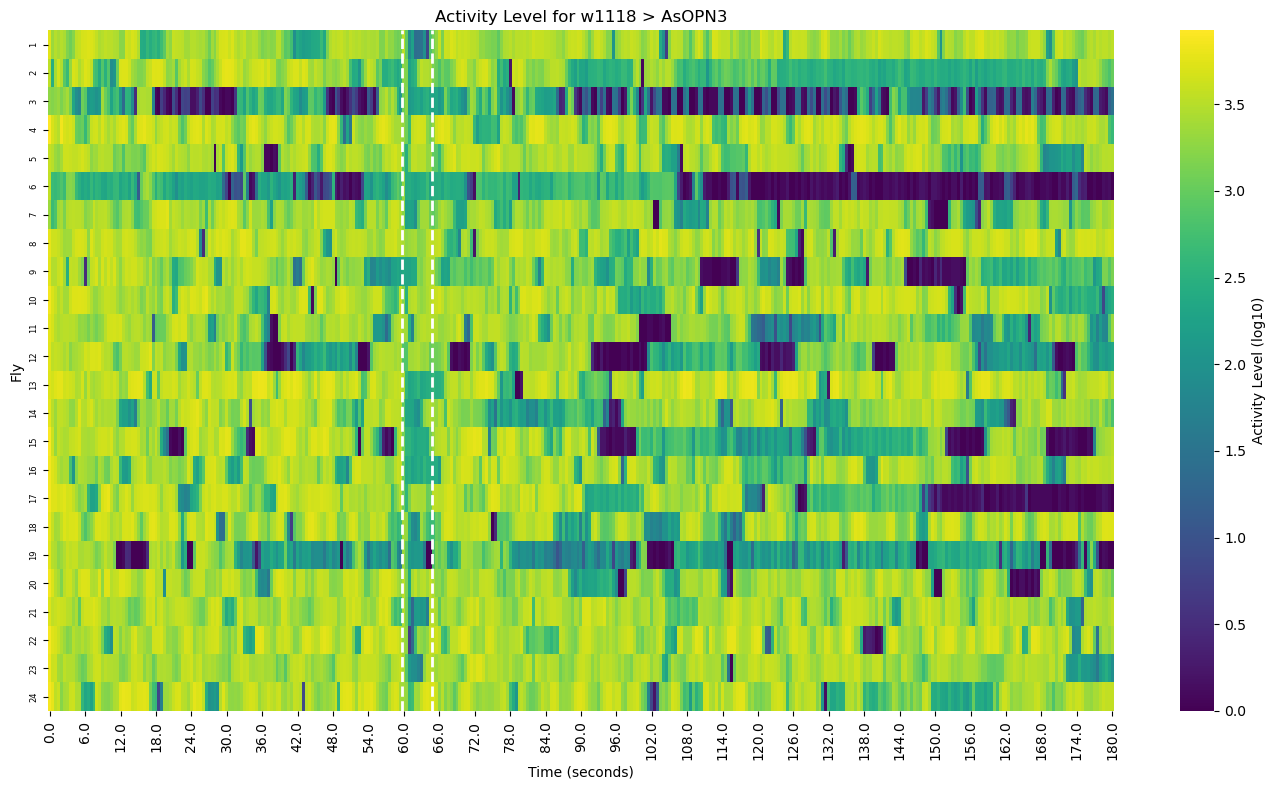

Time filter '5s' applied: 24 files found


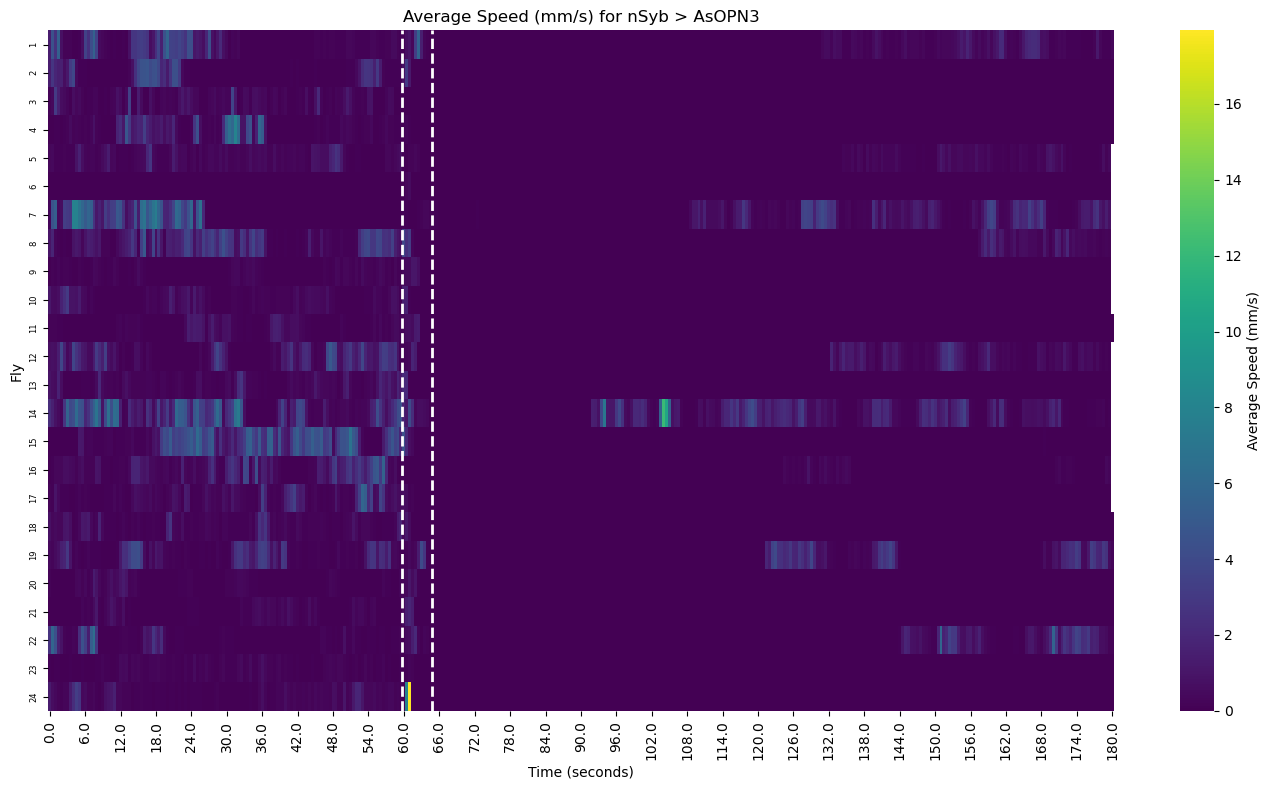

Time filter '5s' applied: 22 files found


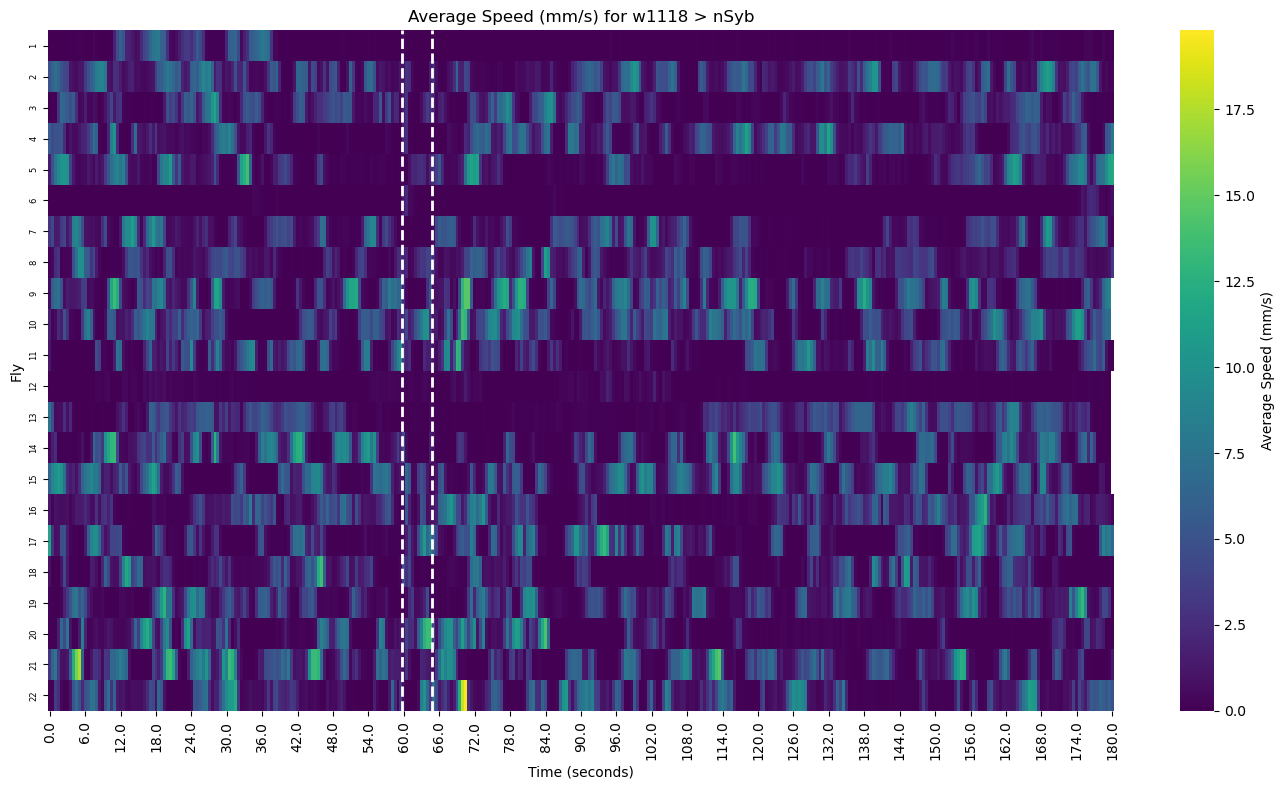

Time filter '5s' applied: 24 files found


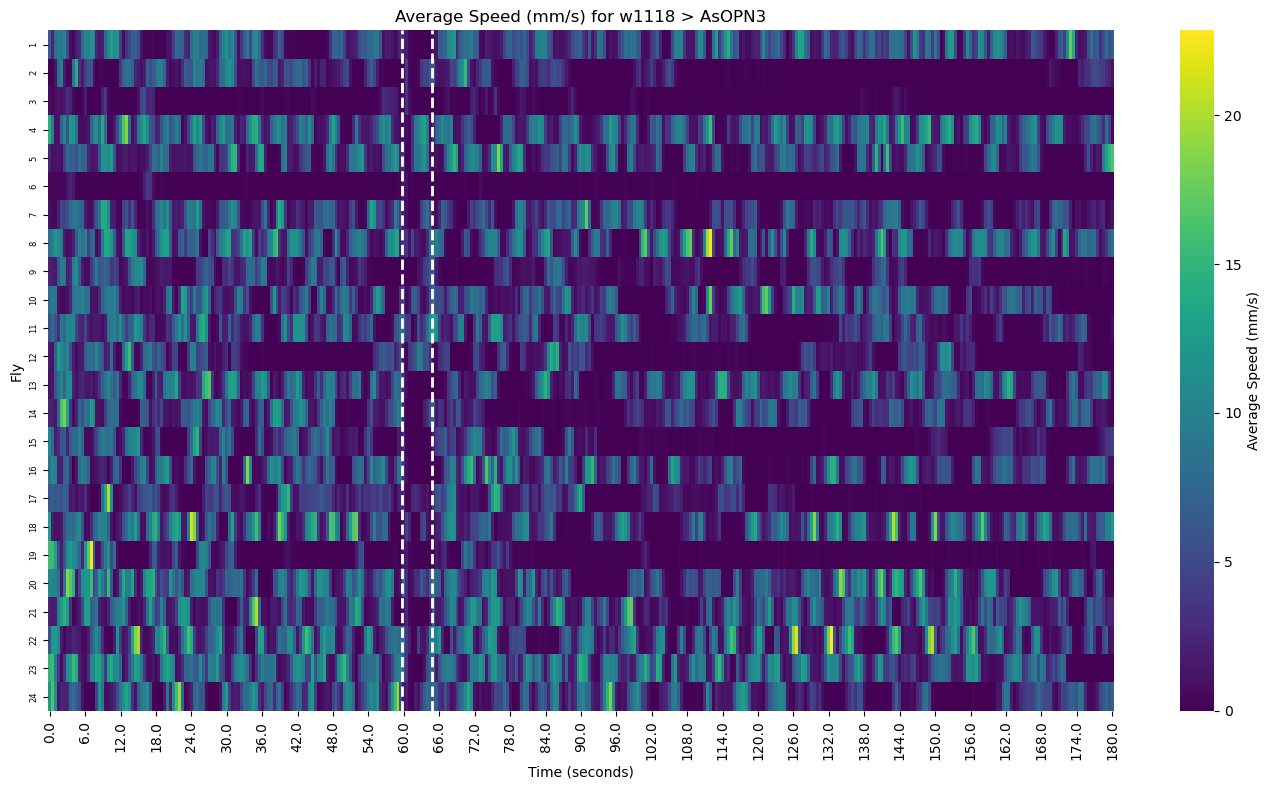

In [39]:
metrics = ["Activity Level", "Speed_Av_mm_per_sec"]
metric_labels = ["Activity Level", "Average Speed (mm/s)"]

# Check if folders exist
folders_exist = {
    "experimental": os.path.exists(exp_path),
    "control1": os.path.exists(control1_path),
    "control2": os.path.exists(control2_path)
}


for metric, metric_label in zip(metrics, metric_labels):
    
    # Load experimental data with time filter
    if folders_exist["experimental"]:
        exp_data = load_csv_data(exp_path, metric, time_filter=time)
        if exp_data is not None:
            fig = create_heatmap(
                exp_data, 
                f"{metric_label} for {transgenicnaming}",
                log_transform=(metric == "Activity Level")
            )
            
            # Save heatmap (uncomment if output_dir is defined)
            # filename = f"{genotypefilename}_{metric.replace(' ', '_').lower()}_heatmap.svg"
            # fig.savefig(os.path.join(output_dir, filename))
            plt.show()
        else:
            print(f"No data found in {exp_path}")
    else:
        print(f"Experimental folder not found: {exp_path}")
    
    # Load and display control data
    if folders_exist["control1"]:
        control1_data = load_csv_data(control1_path, metric, time_filter=time if 'time' in locals() else None)
        if control1_data is not None:
            fig = create_heatmap(
                control1_data, 
                f"{metric_label} for w1118 > {driver}",
                log_transform=(metric == "Activity Level")
            )
            
            # Save heatmap (uncomment if output_dir is defined)
            # filename = f"w1118_{driver}_{metric.replace(' ', '_').lower()}_heatmap.svg"
            # fig.savefig(os.path.join(output_dir, filename))
            plt.show()
    
    if folders_exist["control2"]:
        control2_data = load_csv_data(control2_path, metric, time_filter=time if 'time' in locals() else None)
        if control2_data is not None:
            fig = create_heatmap(
                control2_data, 
                f"{metric_label} for w1118 > {responderrename}",
                log_transform=(metric == "Activity Level")
            )
            
            # Save heatmap (uncomment if output_dir is defined)
            # filename = f"w1118_{responder}_{metric.replace(' ', '_').lower()}_heatmap.svg"
            # fig.savefig(os.path.join(output_dir, filename))
            plt.show()

## Linegraphs

In [ ]:
# Generate Linegraphs
# ===================

for metric, metric_label in zip(metrics, metric_labels):
    print(f"\n{'='*50}")
    print(f"Generating {metric_label} Linegraphs")
    print(f"{'='*50}")
    
    # Prepare data dictionary
    data_dict = {}
    
    # Load experimental data with time filter
    if folders_exist["experimental"]:
        exp_data = load_csv_data(exp_path, metric, time_filter=time if 'time' in locals() else None)
        if exp_data is not None:
            data_dict[transgenicnaming] = exp_data
    
    # Load control data with time filter
    if folders_exist["control1"]:
        control1_data = load_csv_data(control1_path, metric, time_filter=time if 'time' in locals() else None)
        if control1_data is not None:
            data_dict[f"w1118 > {driver}"] = control1_data
    
    if folders_exist["control2"]:
        control2_data = load_csv_data(control2_path, metric, time_filter=time if 'time' in locals() else None)
        if control2_data is not None:
            data_dict[f"w1118 > {responderrename}"] = control2_data
    
    # Create linegraph if we have data
    if data_dict:
        title_parts = list(data_dict.keys())
        if len(title_parts) > 1:
            title = f"{metric_label} for {title_parts[0]} vs. {' vs. '.join(title_parts[1:])}"
        else:
            title = f"{metric_label} for {title_parts[0]}"
            
        fig = create_linegraph(data_dict, title)
        
        # Save linegraph (uncomment if output_dir is defined)
        # filename = f"{genotypefilename}_{metric.replace(' ', '_').lower()}_linegraph.svg"
        # fig.savefig(os.path.join(output_dir, filename))
        plt.show()
    else:
        print(f"No data available for {metric_label} linegraph")

print(f"\n{'='*50}")
print("Analysis Complete!")
# print(f"Figures saved to: {output_dir}")
print(f"{'='*50}")